# Facebook Prophet for Time Series Forecasting in R

## Overview

Prophet (Taylor & Letham, 2018) is a decomposable forecasting model designed for business time series with strong seasonality and irregular observations. It fits a sum of three components:

```
y(t) = trend(t) + seasonality(t) + holidays(t) + ε
```

| Feature | Detail |
|---|---|
| **Trend** | Piecewise linear or logistic (saturating) growth; changepoints detected automatically |
| **Seasonality** | Fourier series: yearly, weekly, daily; custom periods can be added |
| **Holidays / events** | User-supplied event windows |
| **Missing data** | Handled natively — no interpolation needed |
| **Input format** | Data frame with columns `ds` (date) and `y` (value) |

**When Prophet excels:** Daily or sub-daily business data; multiple seasonalities (weekly + annual); known special events; non-regular observation gaps; non-technical forecasters needing interpretable components.

**When to prefer SARIMA/ETS:** High-frequency ecological or clinical data without business-calendar effects; short series; when full statistical control over model structure is needed.

---

## Setup

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'prophet' was built under R version 4.4.3"
Loading required package: Rcpp

Loading required package: rlang


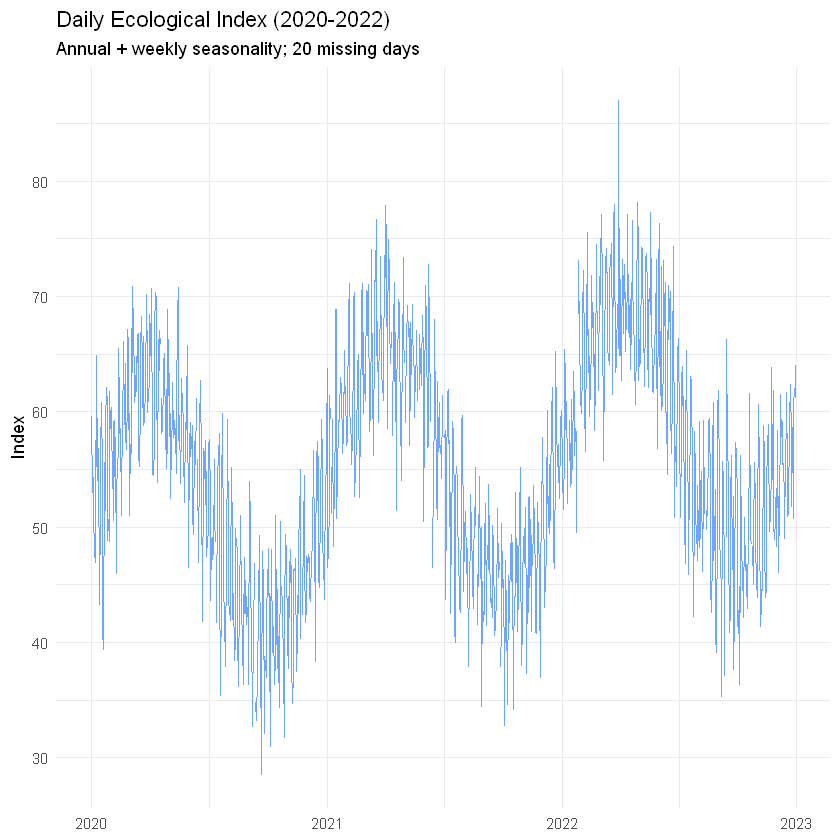

In [1]:
library(tidyverse)
library(ggplot2)
library(prophet)    # install.packages("prophet")
library(patchwork)

set.seed(42)

# ── Simulate daily ecological monitoring data (3 years) ───────────────────────
n_days <- 1095
dates  <- seq(as.Date("2020-01-01"), by="day", length.out=n_days)
t      <- seq_len(n_days)

daily_data <- tibble(
  ds = dates,
  y  = 50 +
       0.01 * t +                                  # gentle trend
       12 * sin(2*pi*t/365.25) +                   # annual cycle
       5  * sin(2*pi*t/7) +                        # weekly cycle
       rnorm(n_days, 0, 4)
) %>%
  mutate(y = pmax(y, 0))

# Add a few missing days (common in real monitoring data)
daily_data$y[sample(1:n_days, 20)] <- NA

ggplot(daily_data, aes(x=ds, y=y)) +
  geom_line(color="#4a8fff", linewidth=0.5, alpha=0.8, na.rm=TRUE) +
  labs(title="Daily Ecological Index (2020-2022)",
       subtitle="Annual + weekly seasonality; 20 missing days",
       x=NULL, y="Index") +
  theme_minimal()

---

## Basic Prophet Model

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the prophet package.
  Please report the issue at <https://github.com/facebook/prophet/issues>."


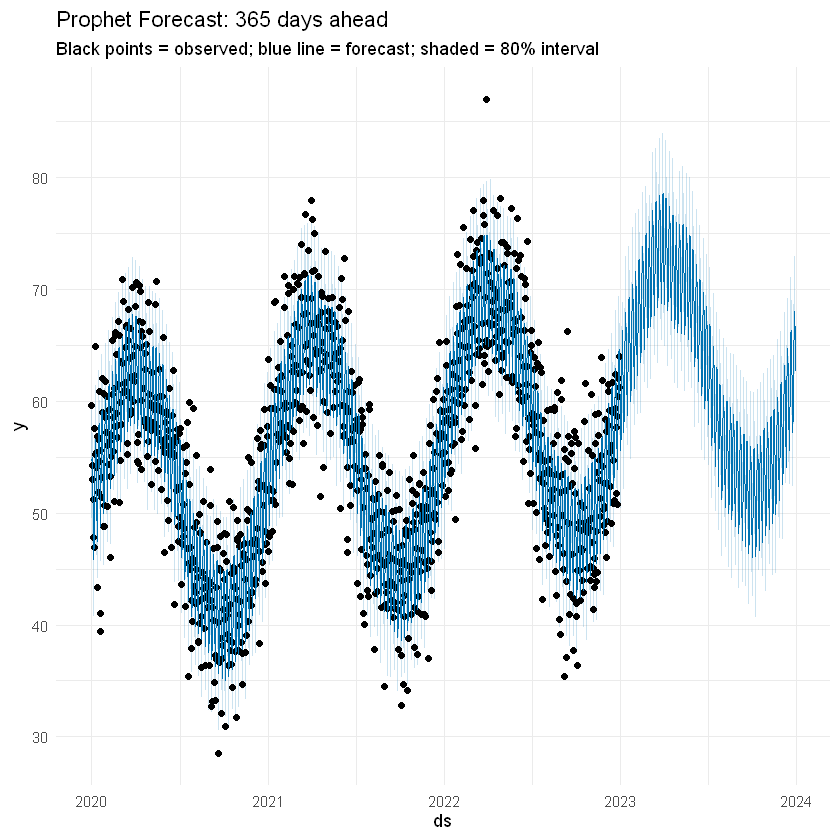

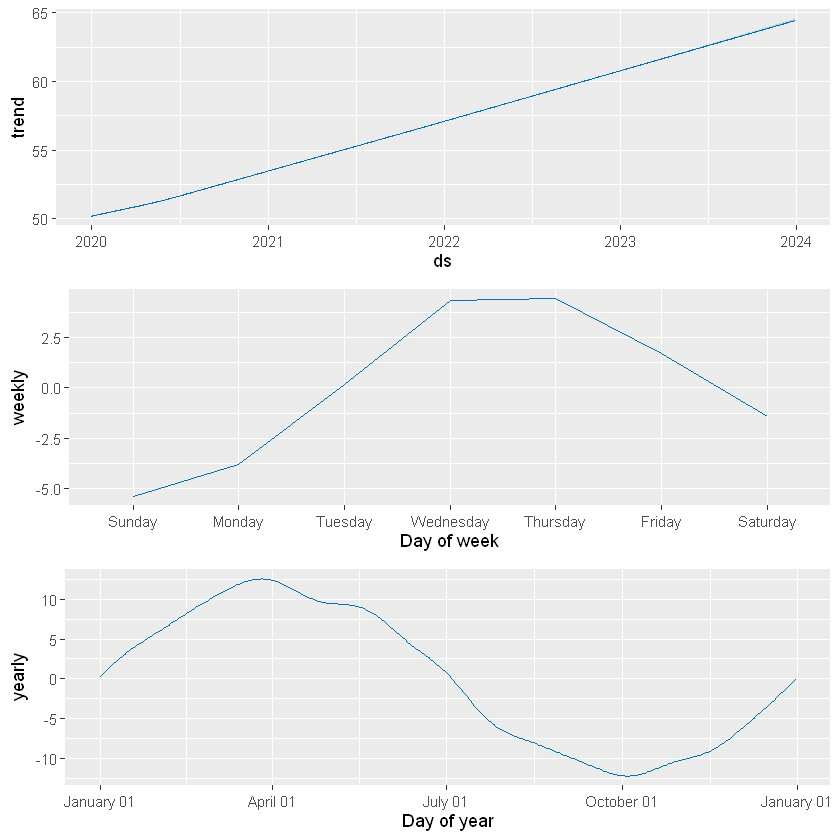

In [2]:
# Fit model — missing values handled automatically
m <- prophet::prophet(
  daily_data,
  yearly.seasonality = TRUE,
  weekly.seasonality = TRUE,
  daily.seasonality  = FALSE,
  seasonality.mode   = "additive"  # or "multiplicative"
)

# Create future dataframe (365 days ahead)
future <- prophet::make_future_dataframe(m, periods=365)
fc     <- predict(m, future)

# Plot forecast
plot(m, fc) +
  labs(title="Prophet Forecast: 365 days ahead",
       subtitle="Black points = observed; blue line = forecast; shaded = 80% interval") +
  theme_minimal()

# Decomposition plot: trend + components
prophet_plot_components(m, fc)

---

## Tuning: Changepoints, Seasonality, and Growth Mode

Disabling daily seasonality. Run prophet with daily.seasonality=TRUE to override this.

Disabling daily seasonality. Run prophet with daily.seasonality=TRUE to override this.

Disabling daily seasonality. Run prophet with daily.seasonality=TRUE to override this.

Disabling daily seasonality. Run prophet with daily.seasonality=TRUE to override this.



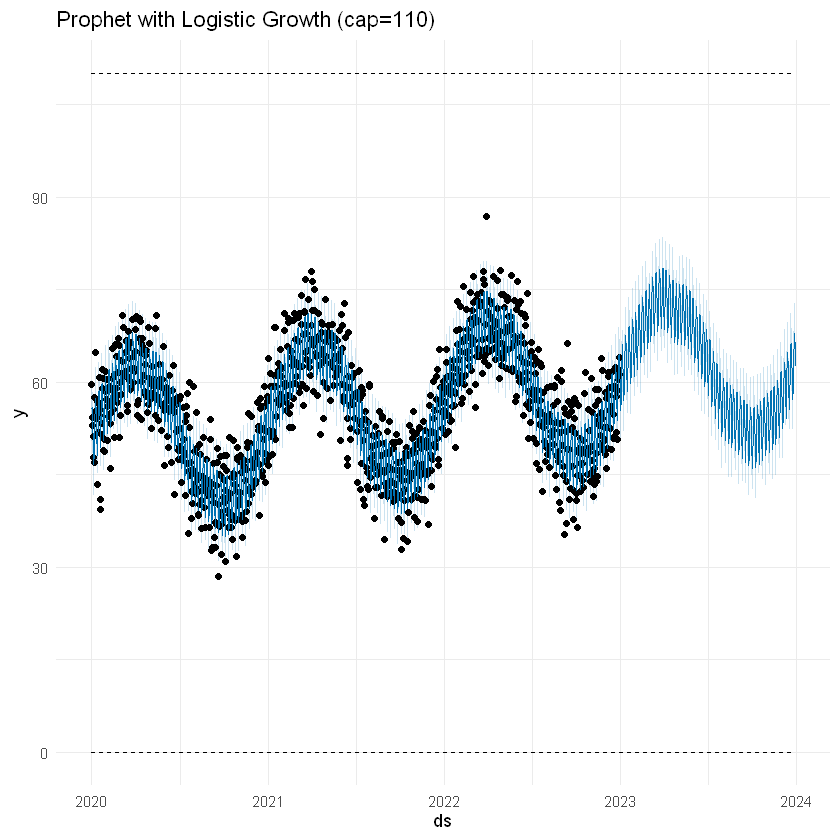

In [3]:
# ── Changepoint sensitivity ───────────────────────────────────────────────────
# changepoint.prior.scale: higher = more flexible trend (more changepoints)
# default = 0.05; range 0.001 – 0.5
m_flex <- prophet::prophet(
  daily_data,
  changepoint.prior.scale = 0.3,   # very flexible trend
  yearly.seasonality=TRUE, weekly.seasonality=TRUE
)
m_stiff <- prophet::prophet(
  daily_data,
  changepoint.prior.scale = 0.001, # very stable trend
  yearly.seasonality=TRUE, weekly.seasonality=TRUE
)

# ── Manual changepoints ───────────────────────────────────────────────────────
# Supply known structural break dates directly
m_manual_cp <- prophet::prophet(
  daily_data,
  changepoints = as.Date(c("2021-03-01","2022-01-01")),  # known events
  yearly.seasonality=TRUE, weekly.seasonality=TRUE
)

# ── Logistic growth (saturating) ─────────────────────────────────────────────
# Use when the series should plateau at a carrying capacity
cap_data <- daily_data %>% mutate(cap=110, floor=0)   # must add cap column
m_logistic <- prophet::prophet(
  cap_data,
  growth = "logistic",
  yearly.seasonality=TRUE, weekly.seasonality=TRUE
)
future_log <- prophet::make_future_dataframe(m_logistic, periods=365) %>%
              mutate(cap=110, floor=0)
fc_log <- predict(m_logistic, future_log)
plot(m_logistic, fc_log) +
  labs(title="Prophet with Logistic Growth (cap=110)") + theme_minimal()

---

## Adding Custom Events / Holidays

In [4]:
# ── Define custom events (e.g. flood events, sampling campaigns) ──────────────
events <- tibble(
  holiday   = c("flood", "flood", "survey_campaign"),
  ds        = as.Date(c("2020-08-15","2021-09-01","2021-06-01")),
  lower_window = c(-2, -2, 0),   # effect starts N days before event
  upper_window = c(5,  5,  7)    # effect ends N days after event
)

m_events <- prophet::prophet(
  daily_data,
  holidays           = events,
  yearly.seasonality = TRUE,
  weekly.seasonality = TRUE
)
fc_events <- predict(m_events,
  prophet::make_future_dataframe(m_events, periods=365))

# ── Custom seasonality: monthly (for aggregated data) ────────────────────────
m_custom <- prophet::prophet(yearly.seasonality=FALSE)
m_custom <- prophet::add_seasonality(
  m_custom,
  name   = "monthly",
  period = 30.5,
  fourier.order = 5   # higher = more flexible; risk of overfitting
)
m_custom <- fit.prophet(m_custom, daily_data)

Disabling daily seasonality. Run prophet with daily.seasonality=TRUE to override this.

Disabling daily seasonality. Run prophet with daily.seasonality=TRUE to override this.



---

## Cross-Validation and Accuracy

y,ds,yhat,yhat_lower,yhat_upper,cutoff
<dbl>,<dttm>,<dbl>,<dbl>,<dbl>,<dttm>
54.44302,2022-01-02,52.45547,47.89243,57.35579,2022-01-01
51.52354,2022-01-03,54.97674,50.03010,59.72878,2022-01-01
56.77262,2022-01-04,58.77576,53.71257,63.52954,2022-01-01
65.36826,2022-01-05,62.71038,57.56492,67.35521,2022-01-01
63.18521,2022-01-06,63.59648,58.62201,67.79056,2022-01-01
58.47619,2022-01-07,61.10875,56.49530,66.09141,2022-01-01


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
,<drtn>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,18 days,12.32945,3.511332,2.866707,0.04837975,0.04006483,0.04747114,0.8490566
2,19 days,13.70828,3.702470,3.062917,0.05126627,0.04066012,0.05030685,0.8301887
3,20 days,14.43549,3.799407,3.088420,0.05162123,0.04066012,0.05049981,0.8113208
4,21 days,14.20802,3.769353,3.052955,0.05079524,0.04066012,0.04972177,0.8113208
5,22 days,13.91741,3.730605,2.958658,0.04947078,0.04051718,0.04837044,0.8113208
6,23 days,16.61681,4.076372,3.252953,0.05603754,0.04284264,0.05440991,0.7735849


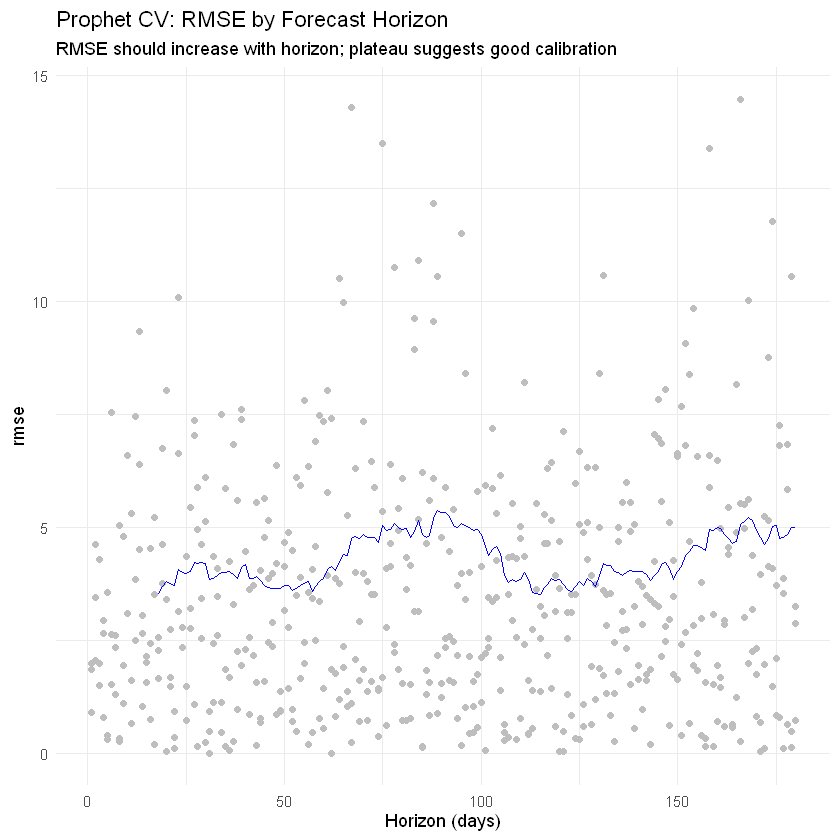

In [10]:
# Bypass string duration parsing by supplying explicit cutoffs
# This avoids the POSIXct/difftime NA issue in generate_cutoffs
cutoffs <- as.POSIXct(c(
  "2022-01-01",
  "2022-04-01",
  "2022-07-01"
), tz = "GMT")

cv_results <- prophet::cross_validation(
  m,
  cutoffs = cutoffs,
  horizon = 180,
  units   = "days"
)
head(cv_results)

# Performance metrics
perf <- prophet::performance_metrics(cv_results)
head(perf)

# Plot RMSE vs. forecast horizon
prophet::plot_cross_validation_metric(cv_results, metric = "rmse") +
  labs(title = "Prophet CV: RMSE by Forecast Horizon",
       subtitle = "RMSE should increase with horizon; plateau suggests good calibration") +
  theme_minimal()

---

## Common Pitfalls

**1. Using Prophet for short series**  
Prophet needs enough data to estimate its seasonal Fourier components. For annual seasonality with `fourier.order=10`, at least 2–3 full annual cycles (730+ observations for daily data) are needed. Short series produce poorly calibrated intervals.

**2. Using additive mode when seasonality scales with level**  
If summer peaks are proportionally larger when the trend is high (not just larger in absolute terms), use `seasonality.mode = "multiplicative"`. Inspect the component plot — if the seasonal component grows with the trend in an additive model, switch.

**3. Over-flexible trends with high `changepoint.prior.scale`**  
High values (>0.3) cause Prophet to fit every local fluctuation in the trend, producing poor forecasts that revert the trend to whatever direction it was heading near the end of the series. Calibrate with cross-validation.

**4. Ignoring the prediction interval calibration**  
Prophet's default uncertainty intervals assume the future variance matches the historical fit residuals. For data with structural non-stationarity, this underestimates true forecast uncertainty. Check with cross-validation coverage.

**5. Using Prophet as a black box without component inspection**  
Always run `prophet_plot_components()` to inspect the decomposed trend, weekly, and annual patterns. These plots reveal whether the model is capturing real seasonal structure or overfitting noise.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*